**Mental Health Risk Assessment System**

Author: Iqra Fatima Umang Conference: ICACTA 2025

This notebook explores the use of Machine Learning algorithms to predict mental health (depression) in students. We compare models like Logistic Regression, SVM, and Random Forest and evaluate their performance using standard metrics.

Abstract
1. Importing Libraries


In [125]:
!pip install tabulate xgboost
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc, accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

## LIBS

from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)



In [126]:
from xgboost import XGBClassifier

In [127]:
from google.colab import files

uploaded = files.upload()

Saving Final Student Depression Dataset.csv to Final Student Depression Dataset (1).csv


In [128]:
import pandas as pd

main = pd.read_csv("Final Student Depression Dataset.csv")

In [129]:
main.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0


In [130]:
main.shape

(27901, 18)

In [131]:
main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  int64  
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  int64  
 6   Work Pressure                          27901 non-null  int64  
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  int64  
 9   Job Satisfaction                       27901 non-null  int64  
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [132]:
## REMOVING ID
main = main.drop(['id'], axis=1)


In [133]:
## CHANGING CATERORICAL TO NUMERICAL (GENDER)
main.loc[main['Gender'] == 'Male', 'Gender'] = 0
main.loc[main['Gender'] == 'Female', 'Gender'] = 1
main.head(3)

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,1,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,0,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0


In [134]:
## CHECKING THE CITY NAMES AND COUNTS
main['City'].value_counts()

,count
City,
Kalyan,1570
Srinagar,1372
Hyderabad,1340
Vasai-Virar,1290
Lucknow,1155
Thane,1139
Ludhiana,1111
Agra,1094
Surat,1078


In [135]:
## REMOVING CITIES WITH LESS THAN 400 STUDENTS
cities_to_remove = main['City'].value_counts()[main['City'].value_counts() < 400]
main = main[~main['City'].isin(cities_to_remove.index)]
main['City'].value_counts()

,count
City,
Kalyan,1570
Srinagar,1372
Hyderabad,1340
Vasai-Virar,1290
Lucknow,1155
Thane,1139
Ludhiana,1111
Agra,1094
Surat,1078


In [136]:
print(main.head())
print(main.shape)

  Gender  Age           City Profession  Academic Pressure  Work Pressure  \
0      0   33  Visakhapatnam    Student                  5              0   
1      1   24      Bangalore    Student                  2              0   
2      0   31       Srinagar    Student                  3              0   
3      1   28       Varanasi    Student                  3              0   
4      1   25         Jaipur    Student                  4              0   

   CGPA  Study Satisfaction  Job Satisfaction     Sleep Duration  \
0  8.97                   2                 0          5-6 hours   
1  5.90                   5                 0          5-6 hours   
2  7.03                   5                 0  Less than 5 hours   
3  5.59                   2                 0          7-8 hours   
4  8.13                   3                 0          5-6 hours   

  Dietary Habits   Degree Have you ever had suicidal thoughts ?  \
0        Healthy  B.Pharm                                   Y

In [137]:
## CHECKING THE PROFESSION NAMES AND COUNTS
main['Profession'].value_counts()

,count
Profession,
Student,27844
Architect,8
Teacher,6
Digital Marketer,3
Chef,2
Content Writer,2
Pharmacist,2
Doctor,2
UX/UI Designer,1


In [138]:
## REMOVING PROFESSIONS != STUDENT DUE LOW COUNTS
main = main.loc[main['Profession'] == 'Student']
main['Profession'].value_counts()

,count
Profession,
Student,27844


In [139]:
## SINCE WE HAVE ONLY ONE PROFESSION, WE CAN DROP THE COLUMN
main = main.drop(['Profession'], axis=1)

In [140]:
## CHECKING THE WORK PRESSURE NAMES AND COUNTS
main['Work Pressure'].value_counts()

,count
Work Pressure,
0,27841
5,2
2,1


In [141]:
#No work pressure mostly so
main = main.drop(['Work Pressure'], axis=1)

In [142]:
## CHECKING AGE DISTRIBUTION
main['Age'].value_counts()

,count
Age,
24,2255
20,2235
28,2128
29,1940
33,1892
25,1780
21,1718
23,1640
18,1586


In [143]:
## REMOVING STUDENTS OLDER THAN 30
main = main.loc[main['Age'] <= 30]
main['Age'].value_counts()

,count
Age,
24,2255
20,2235
28,2128
29,1940
25,1780
21,1718
23,1640
18,1586
19,1560


In [144]:
## CHECKING THE ACADEMIC PRESSURE AND COUNTS
main['Academic Pressure'].value_counts()

,count
Academic Pressure,
3,5785
5,5167
4,4112
1,3546
2,3140
0,7


In [145]:
## CHECKING THE STUDY SATISFACTION AND COUNTS
main['Study Satisfaction'].value_counts()

,count
Study Satisfaction,
4,4825
2,4687
3,4448
1,4336
5,3453
0,8


In [ ]:
#REMOVE 0

In [146]:
## REMOVING JOB SATISFACTION DUE DROP PROFESSION COLUMN
main = main.drop(['Job Satisfaction'], axis=1)
main.head(3)

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
1,1,24,Bangalore,2,5.90,5,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
3,1,28,Varanasi,3,5.59,2,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,1,25,Jaipur,4,8.13,3,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0


In [147]:
## CHECKING THE SLEEP DURATION AND REMOVING 'OTHERS' DUW LOW COUNTS
main['Sleep Duration'].value_counts()

,count
Sleep Duration,
Less than 5 hours,6520
7-8 hours,5734
5-6 hours,4788
More than 8 hours,4703
Others,12


In [148]:
main = main.loc[main['Sleep Duration'] != 'Others']
main['Sleep Duration'].value_counts()

,count
Sleep Duration,
Less than 5 hours,6520
7-8 hours,5734
5-6 hours,4788
More than 8 hours,4703


In [149]:
## CHANGING SLEEP DURATION TO NUMERICAL
main.loc[main['Sleep Duration'] == 'Less than 5 hours', 'Sleep Duration'] = 0
main.loc[main['Sleep Duration'] == '5-6 hours', 'Sleep Duration'] = 1
main.loc[main['Sleep Duration'] == '7-8 hours', 'Sleep Duration'] = 2
main.loc[main['Sleep Duration'] == 'More than 8 hours', 'Sleep Duration'] = 3
main['Sleep Duration'].value_counts()

,count
Sleep Duration,
0,6520
2,5734
1,4788
3,4703


In [150]:
## CHECKING DIEATARY HABITS AND REMOVING 'OTHERS' DUE LOW COUNTS
main['Dietary Habits'].value_counts()
main = main.loc[main['Dietary Habits'] != 'Others']
main['Dietary Habits'].value_counts()

,count
Dietary Habits,
Unhealthy,8356
Moderate,7597
Healthy,5783


In [151]:
## CHANGING DIETARY HABITS TO NUMERICAL
main.loc[main['Dietary Habits'] == 'Healthy', 'Dietary Habits'] = 0
main.loc[main['Dietary Habits'] == 'Unhealthy', 'Dietary Habits'] = 1
main.loc[main['Dietary Habits'] == 'Moderate', 'Dietary Habits'] = 2
main['Dietary Habits'].value_counts()

,count
Dietary Habits,
1,8356
2,7597
0,5783


In [152]:
## CHECKING DEGREE NAMES
main['Degree'].unique()

array(['BSc', 'BCA', 'M.Tech', 'PhD', 'Class 12', 'B.Ed', 'M.Ed', 'MSc',
       'BHM', 'M.Pharm', 'MCA', 'MA', 'B.Pharm', 'B.Com', 'MD', 'BE',
       'BA', 'MBBS', 'B.Arch', 'LLM', 'B.Tech', 'BBA', 'M.Com', 'ME',
       'MBA', 'LLB', 'Others', 'MHM'], dtype=object)

In [153]:
## CREATING NEW DEGREE COLUMN WITH ONLY GRADUATED, POST GRADUATED AND HIGHER SECONDARY
main.loc[main['Degree'].str.contains(r'BSc|BCA|B.Ed|BHM|B.Pharm|B.Com|BE|BA|B.Arch|B.Tech|BBA|LLB', regex=True), 'New_Degree'] = 'Graduated'
main.loc[main['Degree'].str.contains(r'MSc|MCA|M.Ed|M.Pharm|M.Com|ME|MA|M.Arch|M.Tech|MBA|LLM', regex=True), 'New_Degree'] = 'Post Graduated'
main.loc[main['Degree'] == 'Class 12', 'New_Degree'] = 'Higher Secondary'
main = main.loc[main['Degree'] != 'Others']
main['New_Degree'].value_counts()

,count
New_Degree,
Graduated,9783
Higher Secondary,5846
Post Graduated,4871


In [154]:
## CHANGING NEW DEGREE TO NUMERICAL
main.loc[main['New_Degree'] == 'Graduated', 'New_Degree'] = 0
main.loc[main['New_Degree'] == 'Post Graduated', 'New_Degree'] = 1
main.loc[main['New_Degree'] == 'Higher Secondary', 'New_Degree'] = 2
main['New_Degree'].value_counts()

,count
New_Degree,
0,9783
2,5846
1,4871


In [155]:
## CHECKING SUICIDAL THOUGHTS
main['Have you ever had suicidal thoughts ?'].value_counts()

,count
Have you ever had suicidal thoughts ?,
Yes,14272
No,7436


In [156]:
## CHANGING SUICIDAL THOUGHTS TO NUMERICAL
main.loc[main['Have you ever had suicidal thoughts ?'] == 'Yes', 'Have you ever had suicidal thoughts ?'] = 1
main.loc[main['Have you ever had suicidal thoughts ?'] == 'No', 'Have you ever had suicidal thoughts ?'] = 0
main['Have you ever had suicidal thoughts ?'].value_counts()

,count
Have you ever had suicidal thoughts ?,
1,14272
0,7436


In [157]:
## CHECKING THE STUDY HOURS
main['Work/Study Hours'].value_counts()

,count
Work/Study Hours,
10,3358
12,2444
11,2320
8,1928
6,1758
9,1603
7,1585
0,1275
2,1229


In [158]:
## CHECKING THE FINANCIAL STRESS
main['Financial Stress'].value_counts()

,count
Financial Stress,
5.0,5458
4.0,4615
3.0,4048
2.0,3900
1.0,3685


In [159]:
## CHECKING THE FAMILY HISTORY OF MENTAL ILLNESS
main['Family History of Mental Illness'].value_counts()

,count
Family History of Mental Illness,
No,11195
Yes,10513


In [160]:
## CHANGING FAMILY HISTORY OF MENTAL ILLNESS TO NUMERICAL
main.loc[main['Family History of Mental Illness'] == 'Yes', 'Family History of Mental Illness'] = 1
main.loc[main['Family History of Mental Illness'] == 'No', 'Family History of Mental Illness'] = 0
main['Family History of Mental Illness'].value_counts()

,count
Family History of Mental Illness,
0,11195
1,10513


In [161]:
# CHECKING FOR NULL VALUES AND REMOVING
main.isnull().sum()
main = main.dropna()

## CREATING A NEW DF TO CHECK IF THERE IS ANY CORRELATION BETWEEN THE NUMERIC VARIABLES
main_data = main[['Gender', 'Age', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'New_Degree']]
main_data.head(3)

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,New_Degree
1,1,24,2,5.90,5,1,2,0,3,2.0,1,0,0
3,1,28,3,5.59,2,2,2,1,4,5.0,1,1,0
4,1,25,4,8.13,3,1,2,1,1,1.0,0,0,1


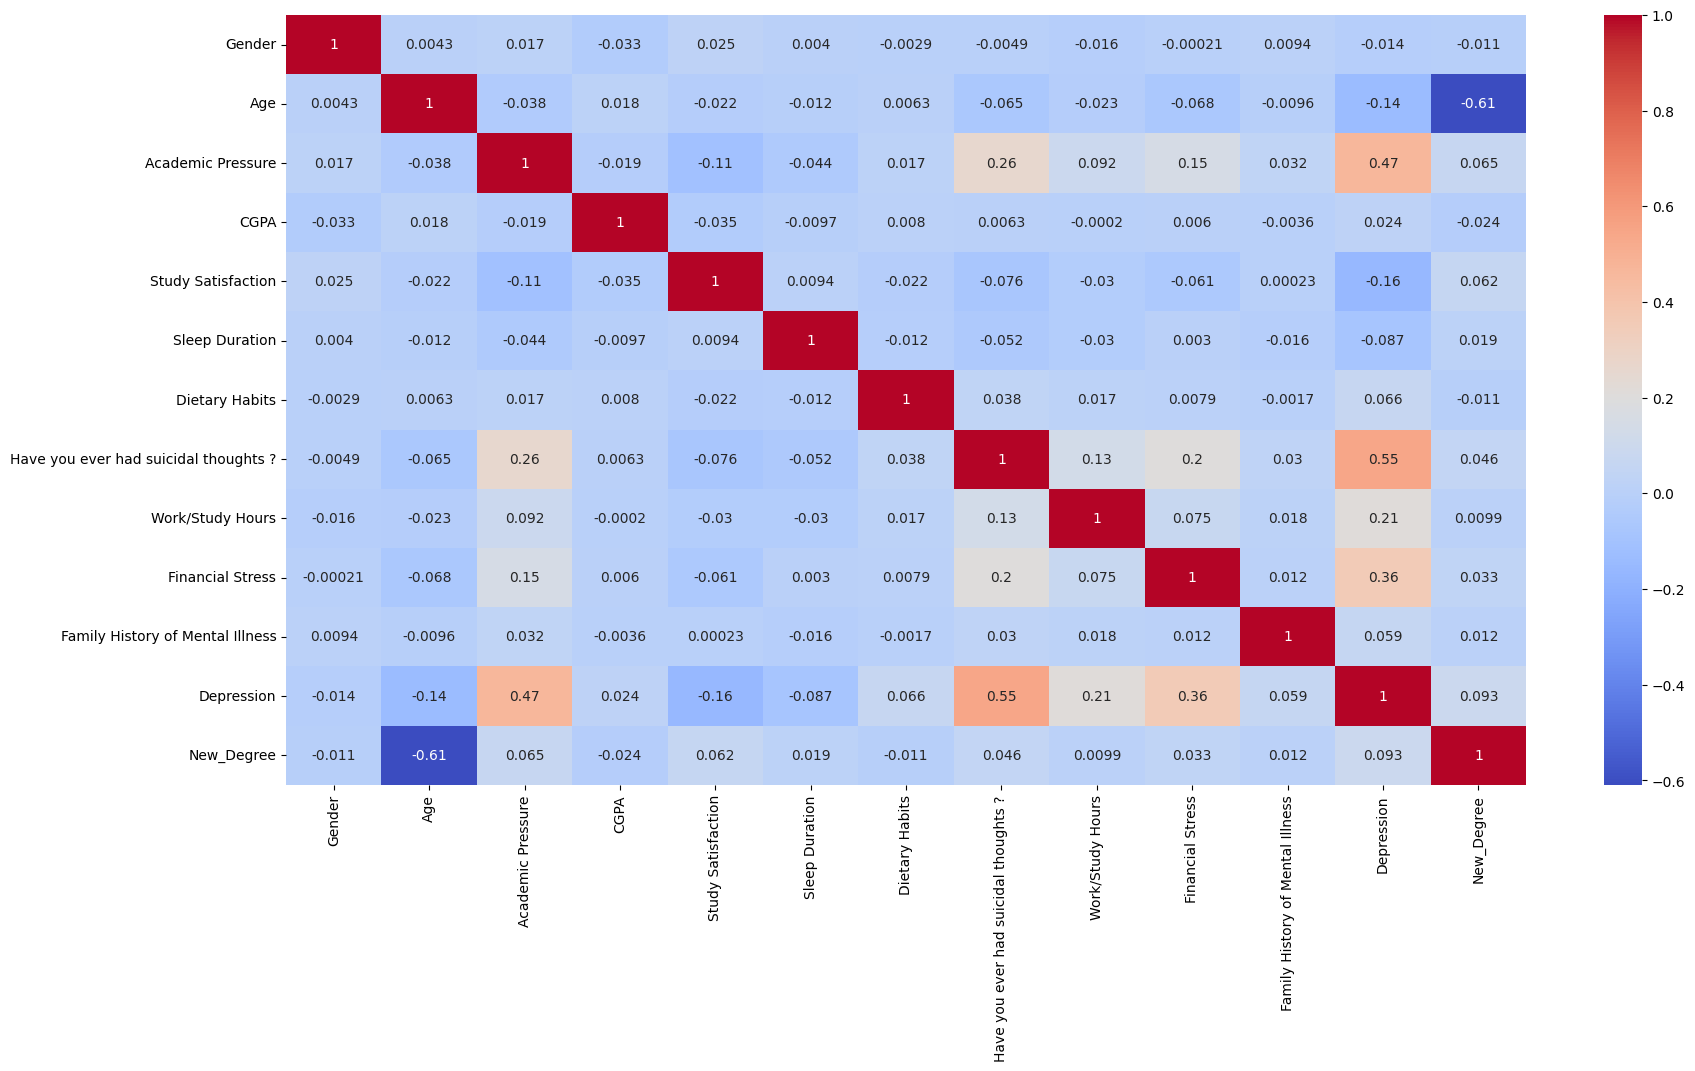

In [162]:
## PLOTTING THE CORRELATION MATRIX
plt.figure(figsize=(20, 10))
sns.heatmap(main_data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [163]:
#Class Balance
print(main_data["Depression"].value_counts())
print(main_data["Depression"].value_counts(normalize=True))

Depression
1    13038
0     7461
Name: count, dtype: int64
Depression
1    0.636031
0    0.363969
Name: proportion, dtype: float64


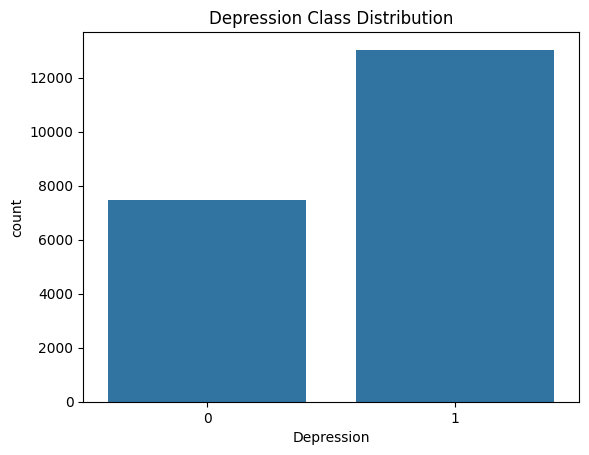

In [164]:
# Class distribution
sns.countplot(x='Depression', data=main_data)
plt.title('Depression Class Distribution')
plt.show()

In [165]:
## CREATING DUMMY VARIABLES FOR THE CITY COLUMN

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(main[['City']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['City']))
## ADJUSTING THE INDEX
encoded_df.index = main.index
main_encoded = pd.concat([main, encoded_df], axis=1)

## CHECKING THE NEW DF
main_encoded.columns

Index(['Gender', 'Age', 'City', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'New_Degree', 'City_Agra', 'City_Ahmedabad', 'City_Bangalore',
       'City_Bhopal', 'City_Chennai', 'City_Delhi', 'City_Faridabad',
       'City_Ghaziabad', 'City_Hyderabad', 'City_Indore', 'City_Jaipur',
       'City_Kalyan', 'City_Kanpur', 'City_Kolkata', 'City_Lucknow',
       'City_Ludhiana', 'City_Meerut', 'City_Mumbai', 'City_Nagpur',
       'City_Nashik', 'City_Patna', 'City_Pune', 'City_Rajkot',
       'City_Srinagar', 'City_Surat', 'City_Thane', 'City_Vadodara',
       'City_Varanasi', 'City_Vasai-Virar', 'City_Visakhapatnam'],
      dtype='object')

In [166]:
## REMOVING THE ORIGINAL CITY AND OLD DEGREE COLUMN
main_encoded = main_encoded.drop(['City', 'Degree'], axis=1)

## **Train-Test Split**

In [167]:
## SPLITTING THE DATA INTO FEATURES AND TARGET
X = main_encoded.drop('Depression', axis=1).values  # Features
y = main_encoded['Depression'].values  # Target

In [168]:
## SPLITTING THE DATA INTO TRAIN AND TEST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [169]:
## NORMALIZING THE DATA FEATURES USING STANDARD SCALER
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Model Training and Evaluation

In [170]:
## TRAINING THE MODEL USING LOGISTIC REGRESSION
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
## SCORE
score = model.score(X_test_scaled, y_test)
print(f"Accuracy: {score*100:.2f}%")

Accuracy: 84.29%


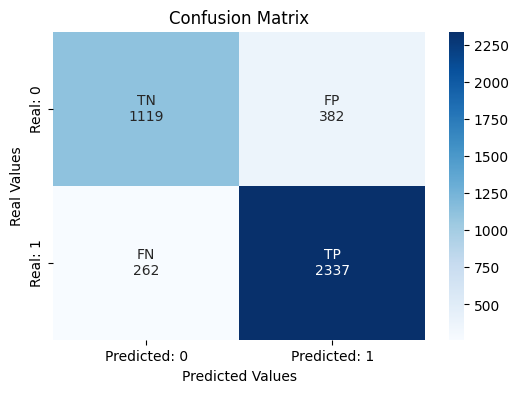

In [171]:
## PLOTTING THE CONFUSION MATRIX
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

# Build combined labels: e.g. "TN\n1200"
labels = np.array([['TN', 'FP'], ['FN', 'TP']])
counts = cm.astype(str)
annot = np.array([f"{labels[i,j]}\n{counts[i,j]}" for i in range(2) for j in range(2)]).reshape(2,2)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=['Predicted: 0', 'Predicted: 1'],
            yticklabels=['Real: 0', 'Real: 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Real Values')
plt.show()

In [172]:
## COMPARING MULTIPLE MODELS TO CHECK THE BEST ONE

## MODELS
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score

In [173]:
## MODELS TO BE COMPARED
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(random_state=42, class_weight='balanced', probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1, scale_pos_weight=scale_pos_weight)
}

In [174]:
from sklearn.metrics import precision_score, recall_score, f1_score

## TRAINING THE MODELS AND STORING ALL METRICS
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Class 1)": precision_score(y_test, y_pred),
        "Recall (Class 1)": recall_score(y_test, y_pred),
        "F1 Score (Class 1)": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("F1 Score (Class 1)", ascending=False)
print(results_df)

                 Model  Accuracy  Precision (Class 1)  Recall (Class 1)  \
2        Random Forest  0.843171             0.857718          0.902270   
3    Gradient Boosting  0.839756             0.861235          0.890727   
8             LightGBM  0.836098             0.892784          0.842632   
0  Logistic Regression  0.834390             0.893120          0.839169   
5  K-Nearest Neighbors  0.818049             0.823838          0.906887   
7              XGBoost  0.828293             0.881902          0.841862   
4                  SVM  0.827805             0.885226          0.836860   
1        Decision Tree  0.766341             0.824950          0.801462   
6          Naive Bayes  0.761463             0.835333          0.776837   

   F1 Score (Class 1)  
2            0.879430  
3            0.875733  
8            0.866983  
0            0.865305  
5            0.863370  
7            0.861417  
4            0.860364  
1            0.813037  
6            0.805024  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



In [176]:
import plotly.express as px

fig = px.bar(plot_df, x="Model", y="Score", color="Metric", barmode="group",
             title="Model Comparison Across All Metrics",
             range_y=[0.5, 1],  # zoomed in — adjust 0.5 based on your lowest score
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(width=1100, height=600, xaxis_tickangle=-45, title_x=0.5)
fig.show()
fig = px.bar(plot_df, x="Model", y="Score", color="Model", facet_col="Metric", facet_col_wrap=2,
             range_y=[0.5, 1],
             text=plot_df["Score"].apply(lambda x: f"{x:.3f}"),
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textposition='outside', textfont_size=9)
fig.update_layout(width=1300, height=800, showlegend=False, title_x=0.5)
fig.update_xaxes(tickangle=-45)
fig.update_yaxes(dtick=0.02, tickformat=".2f")  # gridlines every 0.02, shown as 2 decimals
fig.show()

In [178]:
## THRESHOLD TUNING ON THE BEST MODEL (BY F1)
from sklearn.metrics import precision_recall_curve

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best model by F1:", best_model_name)

probs = best_model.predict_proba(X_test_scaled)[:, 1]
prec, rec, thresh = precision_recall_curve(y_test, probs)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = f1s.argmax()
best_thresh = thresh[best_idx]

y_pred_tuned = (probs >= best_thresh).astype(int)
print(f"Best threshold: {best_thresh:.3f}")
print(classification_report(y_test, y_pred_tuned))

Best model by F1: Random Forest
Best threshold: 0.450
              precision    recall  f1-score   support

           0       0.84      0.70      0.76      1501
           1       0.84      0.93      0.88      2599

    accuracy                           0.84      4100
   macro avg       0.84      0.81      0.82      4100
weighted avg       0.84      0.84      0.84      4100



In [179]:
## THRESHOLD TUNING — OPTIMIZING FOR RECALL (WITH A PRECISION FLOOR)
precision_floor = 0.75  # minimum acceptable precision — adjust based on how many false alarms you can tolerate

# From the same precision_recall_curve computed earlier
valid_idxs = np.where(prec[:-1] >= precision_floor)[0]  # prec/rec have one extra point vs thresh, hence [:-1]

if len(valid_idxs) > 0:
    # among thresholds meeting the precision floor, pick the one with highest recall
    best_recall_idx = valid_idxs[rec[valid_idxs].argmax()]
    recall_thresh = thresh[best_recall_idx]

    y_pred_recall_opt = (probs >= recall_thresh).astype(int)

    print(f"Recall-optimized threshold: {recall_thresh:.3f} (precision floor: {precision_floor})")
    print(classification_report(y_test, y_pred_recall_opt))
else:
    print(f"No threshold achieves precision >= {precision_floor}. Try lowering precision_floor.")

Recall-optimized threshold: 0.220 (precision floor: 0.75)
              precision    recall  f1-score   support

           0       0.93      0.44      0.60      1501
           1       0.75      0.98      0.85      2599

    accuracy                           0.78      4100
   macro avg       0.84      0.71      0.73      4100
weighted avg       0.82      0.78      0.76      4100



In [180]:
## COMPARING ALL THREE THRESHOLD STRATEGIES
print("=== Default Threshold (0.5) ===")
print(classification_report(y_test, best_model.predict(X_test_scaled)))

print("=== F1-Optimal Threshold ===")
print(classification_report(y_test, y_pred_tuned))

print("=== Recall-Optimized Threshold (precision floor 0.75) ===")
print(classification_report(y_test, y_pred_recall_opt))

=== Default Threshold (0.5) ===
              precision    recall  f1-score   support

           0       0.81      0.74      0.78      1501
           1       0.86      0.90      0.88      2599

    accuracy                           0.84      4100
   macro avg       0.84      0.82      0.83      4100
weighted avg       0.84      0.84      0.84      4100

=== F1-Optimal Threshold ===
              precision    recall  f1-score   support

           0       0.84      0.70      0.76      1501
           1       0.84      0.93      0.88      2599

    accuracy                           0.84      4100
   macro avg       0.84      0.81      0.82      4100
weighted avg       0.84      0.84      0.84      4100

=== Recall-Optimized Threshold (precision floor 0.75) ===
              precision    recall  f1-score   support

           0       0.93      0.44      0.60      1501
           1       0.75      0.98      0.85      2599

    accuracy                           0.78      4100
   macro 

### **Note: **While the recall-optimized threshold achieved 98% recall on Class 1, it caused Class 0 recall to drop to 44%, an unacceptable false-positive rate for practical deployment. We therefore selected the F1-optimal threshold (0.450) as our final model, balancing high recall (93%) with reasonable overall performance (84% accuracy).

In [183]:
## FINAL SELECTED MODEL: Random Forest, Threshold = 0.450 (F1-optimal)
final_threshold = best_thresh
final_predictions = y_pred_tuned
print(f"Final model: {best_model_name}, Threshold: {final_threshold:.3f}")
print(classification_report(y_test, final_predictions))

Final model: Random Forest, Threshold: 0.450
              precision    recall  f1-score   support

           0       0.84      0.70      0.76      1501
           1       0.84      0.93      0.88      2599

    accuracy                           0.84      4100
   macro avg       0.84      0.81      0.82      4100
weighted avg       0.84      0.84      0.84      4100



In [184]:
## CROSS-VALIDATION ON FINAL MODEL
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='f1')
print("F1 scores across 5 folds:", cv_scores)
print(f"Mean F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

cv_acc = cross_val_score(best_model, X, y, cv=cv, scoring='accuracy')
print(f"\nMean Accuracy: {cv_acc.mean():.3f} (+/- {cv_acc.std():.3f})")

F1 scores across 5 folds: [0.87546887 0.88543034 0.88214485 0.88046538 0.88153441]
Mean F1: 0.881 (+/- 0.003)

Mean Accuracy: 0.845 (+/- 0.004)


In [185]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=10,  # only tries 10 random combinations, much faster than full grid
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
print(random_search.best_params_, random_search.best_score_)

{'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None} 0.883004983282128


In [186]:
## FINAL TUNED MODEL
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
final_model.fit(X_train, y_train)

# Re-run threshold tuning on this specific model
probs_final = final_model.predict_proba(X_test)[:, 1]
prec, rec, thresh = precision_recall_curve(y_test, probs_final)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = f1s.argmax()
final_threshold = thresh[best_idx]

y_pred_final = (probs_final >= final_threshold).astype(int)
print(f"Final threshold: {final_threshold:.3f}")
print(classification_report(y_test, y_pred_final))

## MAKE ALL EXISTING CELLS BELOW USE THE TUNED MODEL AUTOMATICALLY
best_model = final_model
best_thresh = final_threshold
y_pred_tuned = y_pred_final

Final threshold: 0.435
              precision    recall  f1-score   support

           0       0.85      0.69      0.76      1501
           1       0.84      0.93      0.88      2599

    accuracy                           0.84      4100
   macro avg       0.84      0.81      0.82      4100
weighted avg       0.84      0.84      0.84      4100



In [187]:
## FEATURE IMPORTANCE
importances = final_model.feature_importances_
feat_names = main_encoded.drop(columns=['Depression']).columns

importance_main_data = pd.DataFrame({
    "Feature": feat_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

                                  Feature  Importance
7   Have you ever had suicidal thoughts ?    0.215086
2                       Academic Pressure    0.163009
0                         City (combined)    0.144096
9                        Financial Stress    0.095499
3                                    CGPA    0.082427
8                        Work/Study Hours    0.074022
1                                     Age    0.059065
4                      Study Satisfaction    0.045345
6                          Dietary Habits    0.033924
5                          Sleep Duration    0.033698
11                             New_Degree    0.021780
0                                  Gender    0.016901
10       Family History of Mental Illness    0.015147


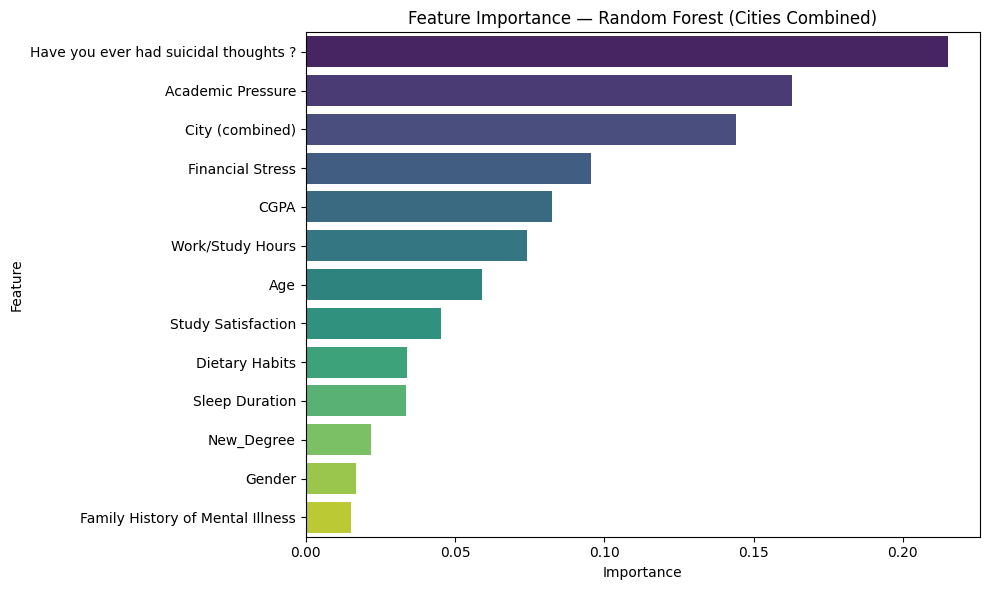

In [188]:
## FEATURE IMPORTANCE — GROUPED CITY
city_importance = importance_main_data[importance_main_data["Feature"].str.startswith("City_")]["Importance"].sum()
non_city = importance_main_data[~importance_main_data["Feature"].str.startswith("City_")]

grouped_importance = pd.concat([
    non_city,
    pd.DataFrame({"Feature": ["City (combined)"], "Importance": [city_importance]})
]).sort_values("Importance", ascending=False)

print(grouped_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_importance, x="Importance", y="Feature", palette='viridis')
plt.title("Feature Importance — Random Forest (Cities Combined)")
plt.tight_layout()
plt.show()

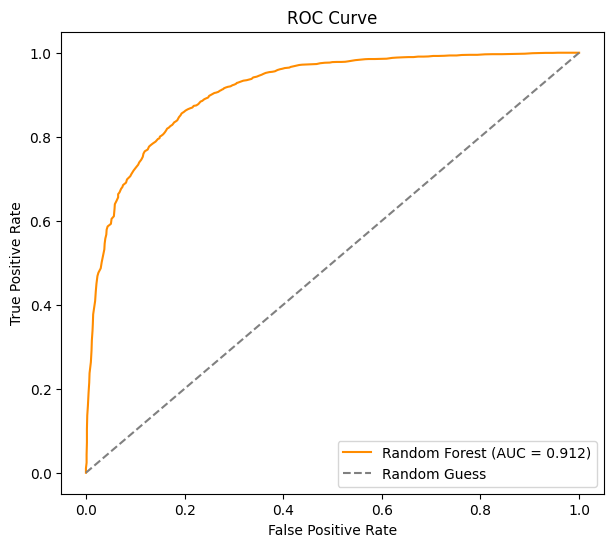

In [189]:
## ROC CURVE
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, probs_final)
auc = roc_auc_score(y_test, probs_final)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
plt.show()

# Locking the model

In [190]:
## SAVE THE FINAL MODEL
import joblib
joblib.dump(best_model, 'final_random_forest_model.pkl')
joblib.dump(final_threshold, 'final_threshold.pkl')
print("Model and threshold saved.")


Model and threshold saved.


In [191]:
from google.colab import files

main_encoded.to_csv("encoded_dataset.csv", index=False)
files.download("encoded_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>